# Decision tree for classification

## Evolution of tree and its variant 

- Decision tree -> random forest -> adaboost -> gradient boosting -> XGBoost

## Introduc to Decision tree

## decision tree motivation 

## how to build decision tree 

- how to select the first node in the tree(root) 
- impurity : tạp chất (không thuần khiết)
- purtity : thuần khiết 

## evaluation metrics 

- GNI impurity : hiệu của 1 với tổng bình phương xác suất 

- idea of GINI impurity : xây dựng cây để impurtity giảm dần 

- total impurity = xác suất * GINI 

## overfitting in tree 

## Classification with Entropy 

- entropy is an information theory metric that measures the impurity or uncertainty in group of observations (dataset)

- surprise = -log2(P)

### Logs (logarithms)


- entropy is used to quantify the similarity or difference in the dataset 

- Information gain (IG) = E(parent) - E(children) 
- maximum IG vì bổ sung nhiều thông tin dẫn theo đó giảm entropy 

## Example 

<img src="/Users/macos/AIO/module 3 /w3/Thứ 4/Ảnh màn hình 2026-02-02 lúc 01.18.11.png" width="800" alt="Mô tả ảnh">

- chọn feature có IG cao nhất làm node gốc 

### Giải thích công thức IG 

- IG(S, A) = Entropy(S) - ∑(|S_v|/|S| * Entropy(S_v))

- Entropy(S) = -∑_{i=1}^{c} p_i * log₂(p_i)

- ∑(|S_v|/|S| * Entropy(S_v))

Phân tích từng phần:
A: Feature đang xem xét (ví dụ: "Outlook")

v: Một giá trị cụ thể của feature A (ví dụ: "Sunny", "Overcast", "Rainy")

S_v: Tập con của S có feature A = v

|S_v|: Số lượng mẫu trong tập con S_v

|S|: Tổng số mẫu trong tập gốc

- đầu tiên chọn node gốc là feature có IG cao nhất 
- IG được tính theo công thức 
- bước 2 : chọn thuộc tính có gini = 0 để làm 1 nhánh , rồi loại trừ thuộc tính đã làm node gốc rồi tính gini để tiếp tục phân nhánh 
- bước 3 : lặp lại cho đến khi đến node lá cuối cùng hoặc đưa ra quyết định 

In [2]:
import pandas as pd 
import numpy as np 

In [9]:
attribute_names = ['age', 'income', 'student', 'credit_rate']
class_name = 'default'
data1 = {
    'age': ['youth', 'youth', 'middle_age', 'senior', 'senior', 'senior', 'middle_age', 'youth', 'youth', 'senior', 'youth', 'middle_age', 'middle_age', 'senior'],
    'income': ['high', 'high', 'high', 'medium', 'low', 'low', 'low', 'medium', 'low', 'medium', 'medium', 'medium', 'high', 'medium'],
    'student': ['no', 'no', 'no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no'],
    'credit_rate': ['fair', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'fair', 'fair', 'excellent', 'excellent', 'fair', 'excellent'],
    'default': ['no', 'no', 'yes', 'yes', 'yes', 'no', 'yes', 'no', 'yes', 'yes', 'yes', 'yes', 'yes', 'no']
}
df1 = pd.DataFrame(data1, columns=data1.keys())
df1.shape

(14, 5)

In [6]:
def gini_impurity(value_counts):
    n = value_counts.sum() 
    return 1 - sum((value_counts / n) ** 2)

class_value_counts = df1[class_name].value_counts() 
print(f'Number of samples in each class is :\n{class_value_counts}')

gini_class = gini_impurity(class_value_counts)
print(f'Gini impurity of class is \n{gini_class}')

Number of samples in each class is :
default
yes    9
no     5
Name: count, dtype: int64
Gini impurity of class is 
0.4591836734693877


In [ ]:
# calculating gini impurity for each atributes 
def gini_split_a(attributes_name):
    attributes_values = df1[attributes_name].value_counts() # đếm số lượng mẫu cho từng thuộc tính 
    gini_A = 0 
    for key in attributes_values.keys() : # duyệt qua từng giá trị duy nhất của thuộc tính 
        df_k = df1[class_name][df1[attributes_name] == key].value_counts() # tạo mask chọn các dòng có thuộc tính = key và lấy nhãn sau đó đếm số lượng mỗi nhãn trong nhóm 
        n_k = attributes_values[key]
        n = df1.shape[0]
        gini_A += (n_k / n) * gini_impurity(df_k)
    return gini_A 

gini_attributes = {}
for key in attribute_names : 
    gini_attributes[key] = gini_split_a(key)
    print(f'Gini for {key} is {gini_attributes[key]}')

print(f'The selected attribute is {min(gini_attributes.keys())}')
# so attribute "age" be selected as root node 

Gini for age is 0.34285714285714286
Gini for income is 0.44047619047619047
Gini for student is 0.3673469387755103
Gini for credit_rate is 0.42857142857142855
The selected attribute is age


Gini_split(A) = Σ [ (|D_v| / |D|) × Gini(D_v) ]
v∈Values(A)

## Iris flower classification (entropy)

In [14]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.datasets import load_iris

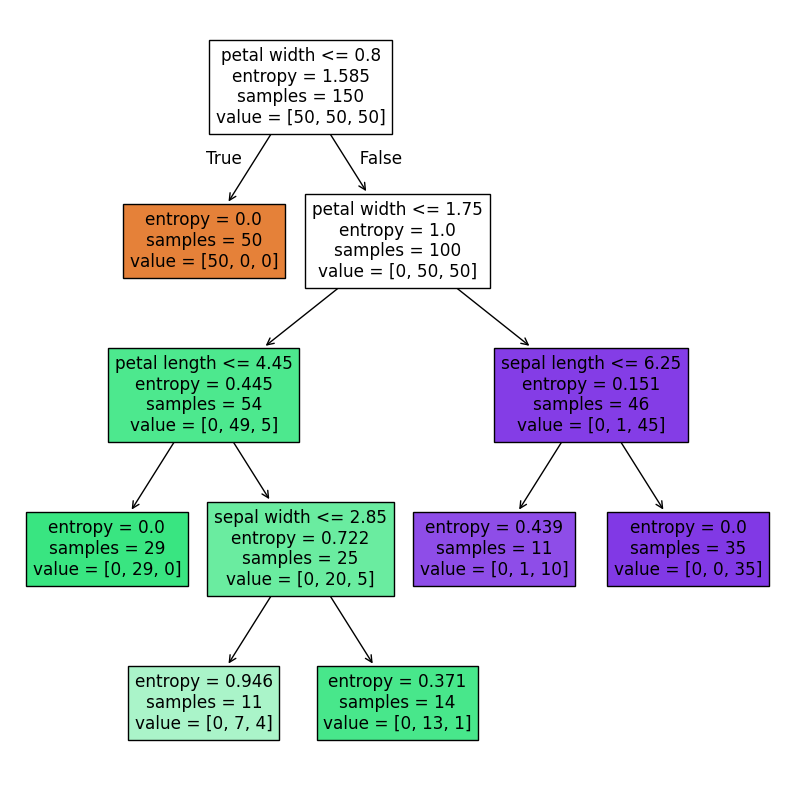

In [ ]:
dataset = load_iris() 
X = dataset.data
Y = dataset.target 

classifier = tree.DecisionTreeClassifier(criterion='entropy' , max_depth = 4 , min_samples_leaf = 10)
classifier.fit(X, Y) # được dùng để huấn luyện mô hình dựa trên tập dữ liệu 
# "Phương thức fit() của đối tượng classifier sẽ thực hiện việc huấn luyện (train) mô hình phân loại (Decision Tree) dựa trên tập dữ liệu (X, y)"
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(
    classifier,
    ax=ax, 
    feature_names=["sepal length", "sepal width", "petal length", "petal width"],
    filled=True
)

plt.show()

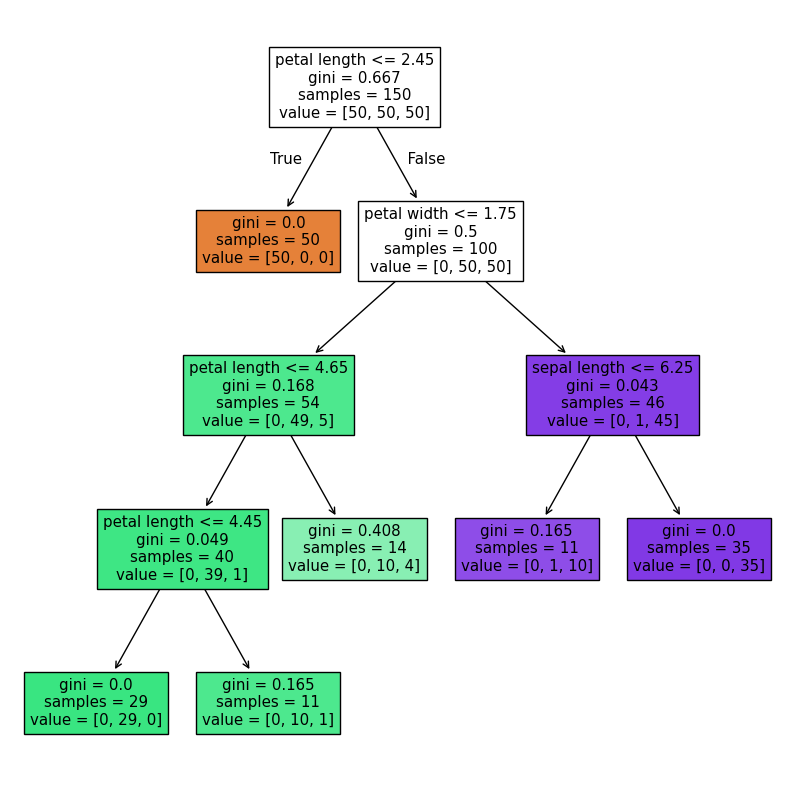

In [20]:
dataset = load_iris() 
X = dataset.data 
Y = dataset.target 

classifier = tree.DecisionTreeClassifier(criterion = 'gini' , max_depth = 4 , min_samples_leaf = 10)
classifier.fit(X , Y)
fig, ax = plt.subplots(figsize=(10, 10))
tree.plot_tree(
    classifier,
    ax=ax, 
    feature_names=["sepal length", "sepal width", "petal length", "petal width"],
    filled=True)
plt.show() 

## Credit Card Fraud Detection 

In [29]:
from sklearn.model_selection import train_test_split

In [35]:
credit_card = pd.read_csv('/Users/macos/AIO/module 3 /w3/Thứ 4/creditcard.csv') 
print('Dataset shape :' , credit_card.shape)

X = credit_card.drop('Class' , axis = 1)
# X = credit_card.iloc[::-1]
# khi ":" mặc định lấy hết và step = -1 tức lấy từ cuối về đầu 
y = credit_card['Class']

X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 42)
# chia bộ dữ liệu thành train và test trong đó : 
# X_train : dl train 
# y_train : nhãn train 
# X_test : dl test 
# y_test : nhãn test 
classifier = DecisionTreeClassifier() 
classifier.fit(X_train , y_train)

Dataset shape : (284807, 31)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [34]:
from sklearn.tree import DecisionTreeClassifier

xtrain , xtest , ytrain , ytest = train_test_split(X , y , test_size = 0.10 , random_state = 42)
# random_state giúp tạo chuỗi số ngẫu nhiên ổn định 
model = DecisionTreeClassifier() 
model.fit(xtrain , ytrain)
print(model.score(xtest , ytest))

0.9964537762016783
